#### 서울시에서 일어나는 범죄와 체감 안전도

In [1]:
import pandas as pd

In [2]:
crime_anal_police = pd.read_csv("../Data/crime_in_Seoul.csv", encoding='euc-kr')


crime_anal_police

,관서명,살인 발생,살인 검거,강도 발생,강도 검거,강간 발생,강간 검거,절도 발생,절도 검거,폭력 발생,폭력 검거
0,중부서,2,2,3,2,105,65,"1,395",477,"1,355","1,170"
1,종로서,3,3,6,5,115,98,"1,070",413,"1,278","1,070"
2,남대문서,1,0,6,4,65,46,"1,153",382,869,794
3,서대문서,2,2,5,4,154,124,"1,812",738,"2,056","1,711"
4,혜화서,3,2,5,4,96,63,"1,114",424,"1,015",861
5,용산서,5,5,14,14,194,173,"1,557",587,"2,050","1,704"
6,성북서,2,2,2,1,86,71,953,409,"1,194","1,015"
7,동대문서,5,5,13,13,173,146,"1,981",814,"2,548","2,227"
8,마포서,8,8,14,10,294,247,"2,555",813,"2,983","2,519"
9,영등포서,14,12,22,20,295,183,"2,964",978,"3,572","2,961"


In [3]:
crime_anal_police.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   관서명     31 non-null     object
 1   살인 발생   31 non-null     int64 
 2   살인 검거   31 non-null     int64 
 3   강도 발생   31 non-null     int64 
 4   강도 검거   31 non-null     int64 
 5   강간 발생   31 non-null     int64 
 6   강간 검거   31 non-null     int64 
 7   절도 발생   31 non-null     object
 8   절도 검거   31 non-null     object
 9   폭력 발생   31 non-null     object
 10  폭력 검거   31 non-null     object
dtypes: int64(6), object(5)
memory usage: 2.8+ KB


In [4]:
# 경찰서 위치 정보
police_address = pd.read_csv("../Data/SeoulPoliceAddress.csv")
police_address.head()

,경찰관서,전화번호,FAX,주소
0,서울중부경찰서,(02)2273-4400,(02)2275-3009,서울 중구 수표로 27
1,서울종로경찰서,(02)3701-4324,(02)3701-4223,서울 종로구 율곡로 46
2,서울남대문경찰서,(02)2096-8324,(02)2096-8337,서울 중구 한강대로 410
3,서울서대문경찰서,(02)335-8192,(02)335-8189,서울 서대문구 통일로 113
4,서울혜화경찰서,(02)762-4400,(02)3158-7133,서울 종로구 창경궁로 112-16


#### crime_anal_police의 관서명 Data를 위치정보와 일치 시키기
: 중부서 - > 서울중부경찰서

In [5]:
# Method
station_name = []
for name in crime_anal_police['관서명']:
  station_name.append('서울'+name[:-1]+"경찰서")
station_name

['서울중부경찰서',
 '서울종로경찰서',
 '서울남대문경찰서',
 '서울서대문경찰서',
 '서울혜화경찰서',
 '서울용산경찰서',
 '서울성북경찰서',
 '서울동대문경찰서',
 '서울마포경찰서',
 '서울영등포경찰서',
 '서울성동경찰서',
 '서울동작경찰서',
 '서울광진경찰서',
 '서울서부경찰서',
 '서울강북경찰서',
 '서울금천경찰서',
 '서울중랑경찰서',
 '서울강남경찰서',
 '서울관악경찰서',
 '서울강서경찰서',
 '서울강동경찰서',
 '서울종암경찰서',
 '서울구로경찰서',
 '서울서초경찰서',
 '서울양천경찰서',
 '서울송파경찰서',
 '서울노원경찰서',
 '서울방배경찰서',
 '서울은평경찰서',
 '서울도봉경찰서',
 '서울수서경찰서']

In [6]:
station_name = list("서울" + crime_anal_police['관서명'].str[:-1]+"경찰서")
station_name

['서울중부경찰서',
 '서울종로경찰서',
 '서울남대문경찰서',
 '서울서대문경찰서',
 '서울혜화경찰서',
 '서울용산경찰서',
 '서울성북경찰서',
 '서울동대문경찰서',
 '서울마포경찰서',
 '서울영등포경찰서',
 '서울성동경찰서',
 '서울동작경찰서',
 '서울광진경찰서',
 '서울서부경찰서',
 '서울강북경찰서',
 '서울금천경찰서',
 '서울중랑경찰서',
 '서울강남경찰서',
 '서울관악경찰서',
 '서울강서경찰서',
 '서울강동경찰서',
 '서울종암경찰서',
 '서울구로경찰서',
 '서울서초경찰서',
 '서울양천경찰서',
 '서울송파경찰서',
 '서울노원경찰서',
 '서울방배경찰서',
 '서울은평경찰서',
 '서울도봉경찰서',
 '서울수서경찰서']

In [7]:
len(station_name) == len(police_address)

True

In [8]:
police_address.head()

,경찰관서,전화번호,FAX,주소
0,서울중부경찰서,(02)2273-4400,(02)2275-3009,서울 중구 수표로 27
1,서울종로경찰서,(02)3701-4324,(02)3701-4223,서울 종로구 율곡로 46
2,서울남대문경찰서,(02)2096-8324,(02)2096-8337,서울 중구 한강대로 410
3,서울서대문경찰서,(02)335-8192,(02)335-8189,서울 서대문구 통일로 113
4,서울혜화경찰서,(02)762-4400,(02)3158-7133,서울 종로구 창경궁로 112-16


In [9]:
from geopy.geocoders import Nominatim
import requests

In [10]:
def get_lat_lng(address):
  try:
    geolocoder=Nominatim(user_agent='South Korea', timeout=None)
    geo = geolocoder.geocode(address)
    lat_lng = {"lat" : str(geo.latitude), "lng" : str(geo.longitude)}
  except:
    lat_lng = {"lat" : str(0), "lng" : str(0)}
  finally:
    return lat_lng

In [11]:
# 위도 경도 찾기
station_lat = []
station_lng = []

for name in police_address['주소']:
  print(name)
  response = get_lat_lng(name)
  station_lat.append(response['lat'])
  station_lng.append(response['lng'])

서울 중구 수표로 27
서울 종로구 율곡로 46
서울 중구 한강대로 410
서울 서대문구 통일로 113
서울 종로구 창경궁로 112-16
서울 용산구 원효로89길 24
서울 성북구 보문로 170
서울 동대문구 약령시로21길 29
서울 마포구 마포대로 183
서울시 영등포구 국회대로 608
서울 성동구 왕십리광장로 9
서울 동작구 노량진로 148
서울 광진구 자양로 167
서울 은평구 통일로 757
서울 강북구 오패산로 406
서울 관악구 남부순환로 1435
서울 중랑구 신내역로3길 40-10
서울 강남구 테헤란로114길 11
서울 관악구 관악로5길 33
서울 양천구 화곡로 73
서울 강동구 성내로 57
서울 성북구 종암로 135
서울 구로구 가마산로 235
서울 서초구 반포대로 179
서울 양천구 목동동로 99
서울 송파구 중대로 221
서울 노원구 노원로 283
서울 서초구 동작대로 204
서울 은평구 연서로 365
서울 도봉구 노해로 403
서울 강남구 개포로 617


In [12]:
police_address['lat'] = station_lat
police_address['lng'] = station_lng
police_address

,경찰관서,전화번호,FAX,주소,lat,lng
0,서울중부경찰서,(02)2273-4400,(02)2275-3009,서울 중구 수표로 27,37.5676114,126.9902416
1,서울종로경찰서,(02)3701-4324,(02)3701-4223,서울 종로구 율곡로 46,37.5773586,126.9881165
2,서울남대문경찰서,(02)2096-8324,(02)2096-8337,서울 중구 한강대로 410,37.5547114,126.9735286
3,서울서대문경찰서,(02)335-8192,(02)335-8189,서울 서대문구 통일로 113,37.58773,126.946153
4,서울혜화경찰서,(02)762-4400,(02)3158-7133,서울 종로구 창경궁로 112-16,37.5714893,126.9986962
5,서울용산경찰서,(02)2198-0267,(02)2198-0325,서울 용산구 원효로89길 24,37.5404818,126.9679932
6,서울성북경찰서,(02)920-1324,(02)920-1661,서울 성북구 보문로 170,37.5897062,127.0165107
7,서울동대문경찰서,(02)3295-0110,(02)961-4849,서울 동대문구 약령시로21길 29,37.5851345,127.045778
8,서울마포경찰서,(02)3149-6324,(02)3149-6327,서울 마포구 마포대로 183,37.5508598,126.9543356
9,서울영등포경찰서,(02)2118-9324,(02)2118-9461,서울시 영등포구 국회대로 608,37.5263507,126.9006677


#### 경찰서의 주소 중 구 이름만 추출하기

In [13]:
gu_name = []

for name in police_address['주소']:
  temp = name.split()
  temp_gu = [gu for gu in temp if gu[-1] == '구'][0]
  gu_name.append(temp_gu)

crime_anal_police['구별'] = gu_name
crime_anal_police.head()

,관서명,살인 발생,살인 검거,강도 발생,강도 검거,강간 발생,강간 검거,절도 발생,절도 검거,폭력 발생,폭력 검거,구별
0,중부서,2,2,3,2,105,65,"1,395",477,"1,355","1,170",중구
1,종로서,3,3,6,5,115,98,"1,070",413,"1,278","1,070",종로구
2,남대문서,1,0,6,4,65,46,"1,153",382,869,794,중구
3,서대문서,2,2,5,4,154,124,"1,812",738,"2,056","1,711",서대문구
4,혜화서,3,2,5,4,96,63,"1,114",424,"1,015",861,종로구


In [14]:
len(gu_name)

31

In [15]:
len(set(gu_name))

23

> 서울시 구는 25개로 되어 있는데 23개의 구만 보임

서울시 구는 25개인데 경찰서 수는 31개로 동일한 구에 경찰서가 1개이상 있는 지역이 있다.

In [16]:
# 관서명과 구별 이름 확인
crime_anal_police.loc[:,['관서명','구별']]

,관서명,구별
0,중부서,중구
1,종로서,종로구
2,남대문서,중구
3,서대문서,서대문구
4,혜화서,종로구
5,용산서,용산구
6,성북서,성북구
7,동대문서,동대문구
8,마포서,마포구
9,영등포서,영등포구


In [17]:
# 금천서의 관악구 -> 금천구

crime_anal_police.loc[crime_anal_police['관서명'] == '금천서','구별'] = '금천구'
crime_anal_police.loc[crime_anal_police['관서명'] == '금천서']

,관서명,살인 발생,살인 검거,강도 발생,강도 검거,강간 발생,강간 검거,절도 발생,절도 검거,폭력 발생,폭력 검거,구별
15,금천서,3,4,6,6,151,122,"1,567",888,"2,054","1,776",금천구


In [18]:
# 강서서 : 양천구 -> 강서구

crime_anal_police.loc[crime_anal_police['관서명'] == '강서서','구별'] = '강서구'
crime_anal_police.loc[crime_anal_police['관서명'] == '강서서']

,관서명,살인 발생,살인 검거,강도 발생,강도 검거,강간 발생,강간 검거,절도 발생,절도 검거,폭력 발생,폭력 검거,구별
19,강서서,7,8,13,13,262,191,"2,096","1,260","3,207","2,718",강서구


In [19]:
# 절도발생 부터 폭력검거 까지의 dtype을 int로 변환


crime_anal_police['절도 발생'] = \
  crime_anal_police['절도 발생'].str.replace(",","").astype(int)
crime_anal_police['절도 검거'] = \
  crime_anal_police['절도 검거'].str.replace(",","").astype(int)
crime_anal_police['폭력 발생'] = \
  crime_anal_police['폭력 발생'].str.replace(",","").astype(int)
crime_anal_police['폭력 검거'] = \
  crime_anal_police['폭력 검거'].str.replace(",","").astype(int)

crime_anal_police.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   관서명     31 non-null     object
 1   살인 발생   31 non-null     int64 
 2   살인 검거   31 non-null     int64 
 3   강도 발생   31 non-null     int64 
 4   강도 검거   31 non-null     int64 
 5   강간 발생   31 non-null     int64 
 6   강간 검거   31 non-null     int64 
 7   절도 발생   31 non-null     int64 
 8   절도 검거   31 non-null     int64 
 9   폭력 발생   31 non-null     int64 
 10  폭력 검거   31 non-null     int64 
 11  구별      31 non-null     object
dtypes: int64(10), object(2)
memory usage: 3.0+ KB


In [20]:
import warnings
warnings.filterwarnings('ignore')

### 관서명 --> 구별 기준으로 변경

In [21]:
# 구별로 데이터를 정리한다.

# gu_data = \
# crime_anal_police.pivot_table(
#   ['관서명'],
#   index=['구'],
#   aggfunc='sum'
# )
# gu_data.head()
crim_anal = \
pd.pivot_table(
  crime_anal_police,
  index='구별',
  aggfunc='sum'
)

crim_anal


,강간 검거,강간 발생,강도 검거,강도 발생,관서명,살인 검거,살인 발생,절도 검거,절도 발생,폭력 검거,폭력 발생
구별,,,,,,,,,,,
강남구,349,449,18,21,강남서수서서,10,13,1650,3850,3705,4284
강동구,123,156,8,6,강동서,3,4,789,2366,2248,2712
강북구,126,153,13,14,강북서,8,7,618,1434,2348,2649
강서구,191,262,13,13,강서서,8,7,1260,2096,2718,3207
관악구,221,320,14,12,관악서,8,9,827,2706,2642,3298
광진구,220,240,26,14,광진서,4,4,1277,3026,2180,2625
구로구,164,281,11,15,구로서,6,8,889,2335,2432,3007
금천구,122,151,6,6,금천서,4,3,888,1567,1776,2054
노원구,121,197,7,7,노원서,10,10,801,2193,2329,2723


In [22]:
# 각 범죄별 검거율 구하기
crim_anal['강간검거율'] = crim_anal['강간 검거'] / crim_anal['강간 발생'] * 100
crim_anal['강도검거율'] = crim_anal['강도 검거'] / crim_anal['강도 발생'] * 100
crim_anal['살인검거율'] = crim_anal['살인 검거'] / crim_anal['살인 발생'] * 100
crim_anal['절도검거율'] = crim_anal['절도 검거'] / crim_anal['절도 발생'] * 100
crim_anal['폭력검거율'] = crim_anal['폭력 검거'] / crim_anal['폭력 발생'] * 100

crim_anal

,강간 검거,강간 발생,강도 검거,강도 발생,관서명,살인 검거,살인 발생,절도 검거,절도 발생,폭력 검거,폭력 발생,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율
구별,,,,,,,,,,,,,,,,
강남구,349,449,18,21,강남서수서서,10,13,1650,3850,3705,4284,77.728285,85.714286,76.923077,42.857143,86.484594
강동구,123,156,8,6,강동서,3,4,789,2366,2248,2712,78.846154,133.333333,75.000000,33.347422,82.890855
강북구,126,153,13,14,강북서,8,7,618,1434,2348,2649,82.352941,92.857143,114.285714,43.096234,88.637222
강서구,191,262,13,13,강서서,8,7,1260,2096,2718,3207,72.900763,100.000000,114.285714,60.114504,84.752105
관악구,221,320,14,12,관악서,8,9,827,2706,2642,3298,69.062500,116.666667,88.888889,30.561715,80.109157
광진구,220,240,26,14,광진서,4,4,1277,3026,2180,2625,91.666667,185.714286,100.000000,42.200925,83.047619
구로구,164,281,11,15,구로서,6,8,889,2335,2432,3007,58.362989,73.333333,75.000000,38.072805,80.877951
금천구,122,151,6,6,금천서,4,3,888,1567,1776,2054,80.794702,100.000000,133.333333,56.668794,86.465433
노원구,121,197,7,7,노원서,10,10,801,2193,2329,2723,61.421320,100.000000,100.000000,36.525308,85.530665


In [23]:
# 검거건수는 삭제

del crim_anal['강간 검거']
del crim_anal['강도 검거']
del crim_anal['살인 검거']
del crim_anal['절도 검거']
del crim_anal['폭력 검거']

crim_anal

,강간 발생,강도 발생,관서명,살인 발생,절도 발생,폭력 발생,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율
구별,,,,,,,,,,,
강남구,449,21,강남서수서서,13,3850,4284,77.728285,85.714286,76.923077,42.857143,86.484594
강동구,156,6,강동서,4,2366,2712,78.846154,133.333333,75.000000,33.347422,82.890855
강북구,153,14,강북서,7,1434,2649,82.352941,92.857143,114.285714,43.096234,88.637222
강서구,262,13,강서서,7,2096,3207,72.900763,100.000000,114.285714,60.114504,84.752105
관악구,320,12,관악서,9,2706,3298,69.062500,116.666667,88.888889,30.561715,80.109157
광진구,240,14,광진서,4,3026,2625,91.666667,185.714286,100.000000,42.200925,83.047619
구로구,281,15,구로서,8,2335,3007,58.362989,73.333333,75.000000,38.072805,80.877951
금천구,151,6,금천서,3,1567,2054,80.794702,100.000000,133.333333,56.668794,86.465433
노원구,197,7,노원서,10,2193,2723,61.421320,100.000000,100.000000,36.525308,85.530665


In [24]:
# 검거율이 100이 넘는 경우에는 100으로 변경한다.

for i in crim_anal.loc[:,'강간검거율' : '폭력검거율'].columns:
  crim_anal.loc[crim_anal[i] > 100, i] = 100
crim_anal

,강간 발생,강도 발생,관서명,살인 발생,절도 발생,폭력 발생,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율
구별,,,,,,,,,,,
강남구,449,21,강남서수서서,13,3850,4284,77.728285,85.714286,76.923077,42.857143,86.484594
강동구,156,6,강동서,4,2366,2712,78.846154,100.000000,75.000000,33.347422,82.890855
강북구,153,14,강북서,7,1434,2649,82.352941,92.857143,100.000000,43.096234,88.637222
강서구,262,13,강서서,7,2096,3207,72.900763,100.000000,100.000000,60.114504,84.752105
관악구,320,12,관악서,9,2706,3298,69.062500,100.000000,88.888889,30.561715,80.109157
광진구,240,14,광진서,4,3026,2625,91.666667,100.000000,100.000000,42.200925,83.047619
구로구,281,15,구로서,8,2335,3007,58.362989,73.333333,75.000000,38.072805,80.877951
금천구,151,6,금천서,3,1567,2054,80.794702,100.000000,100.000000,56.668794,86.465433
노원구,197,7,노원서,10,2193,2723,61.421320,100.000000,100.000000,36.525308,85.530665


In [25]:
# Column이름 변경

crim_anal.rename(
  columns={
    '강간 발생' : '강간',
    '강도 발생' : '강도',
    '살인 발생' : '살인',
    '절도 발생' : '절도',
    '폭력 발생' : '폭력',
  }, inplace=True
)

crim_anal

,강간,강도,관서명,살인,절도,폭력,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율
구별,,,,,,,,,,,
강남구,449,21,강남서수서서,13,3850,4284,77.728285,85.714286,76.923077,42.857143,86.484594
강동구,156,6,강동서,4,2366,2712,78.846154,100.000000,75.000000,33.347422,82.890855
강북구,153,14,강북서,7,1434,2649,82.352941,92.857143,100.000000,43.096234,88.637222
강서구,262,13,강서서,7,2096,3207,72.900763,100.000000,100.000000,60.114504,84.752105
관악구,320,12,관악서,9,2706,3298,69.062500,100.000000,88.888889,30.561715,80.109157
광진구,240,14,광진서,4,3026,2625,91.666667,100.000000,100.000000,42.200925,83.047619
구로구,281,15,구로서,8,2335,3007,58.362989,73.333333,75.000000,38.072805,80.877951
금천구,151,6,금천서,3,1567,2054,80.794702,100.000000,100.000000,56.668794,86.465433
노원구,197,7,노원서,10,2193,2723,61.421320,100.000000,100.000000,36.525308,85.530665


---
### 데이터의 정규화(Normalization)
- 강도와 살인은 2자릿수 이나 절도와 폭력은 4자릿수
- 각각의 범죄 발생 건수를 비슷한 범위에 놓고 비교하는 것이 편리하다.
- 각 항목의 값을 최대 1로 계산하여 그 비중자체로 분석

In [26]:
# 머신러닝 모듈
from sklearn import preprocessing

In [27]:
# 정규화를 진행할 컬럼 설정
col = ['강간','강도','살인','절도','폭력']

In [28]:
import numpy as np

In [29]:
x = crim_anal[col].values
x

array([[ 449,   21,   13, 3850, 4284],
       [ 156,    6,    4, 2366, 2712],
       [ 153,   14,    7, 1434, 2649],
       [ 262,   13,    7, 2096, 3207],
       [ 320,   12,    9, 2706, 3298],
       [ 240,   14,    4, 3026, 2625],
       [ 281,   15,    8, 2335, 3007],
       [ 151,    6,    3, 1567, 2054],
       [ 197,    7,   10, 2193, 2723],
       [ 102,    9,    3, 1063, 1487],
       [ 173,   13,    5, 1981, 2548],
       [ 285,    9,    5, 1865, 1910],
       [ 294,   14,    8, 2555, 2983],
       [ 154,    5,    2, 1812, 2056],
       [ 393,    9,    8, 2635, 2399],
       [ 126,    9,    4, 1607, 1612],
       [ 150,    5,    5, 1785, 2209],
       [ 220,   13,   11, 3239, 3295],
       [ 120,    6,    3, 1890, 2509],
       [ 295,   22,   14, 2964, 3572],
       [ 194,   14,    5, 1557, 2050],
       [ 166,    9,    3, 1914, 2653],
       [ 211,   11,    6, 2184, 2293],
       [ 170,    9,    3, 2548, 2224],
       [ 187,   11,   13, 2135, 2847]])

In [30]:
# 최대값과 최소값 선택
min_max_scaler = preprocessing.MinMaxScaler()
min_max_scaler

MinMaxScaler()

In [31]:
# 정규화 시킬 최종값은 비율로 게산되기 때문에 float설정
x_scaled = min_max_scaler.fit_transform(x)
x_scaled

array([[1.        , 0.94117647, 0.91666667, 1.        , 1.        ],
       [0.1556196 , 0.05882353, 0.16666667, 0.46752781, 0.43796925],
       [0.14697406, 0.52941176, 0.41666667, 0.13311805, 0.41544512],
       [0.4610951 , 0.47058824, 0.41666667, 0.37064944, 0.61494458],
       [0.62824207, 0.41176471, 0.58333333, 0.58952278, 0.64747944],
       [0.39769452, 0.52941176, 0.16666667, 0.70434159, 0.4068645 ],
       [0.51585014, 0.58823529, 0.5       , 0.45640474, 0.5434394 ],
       [0.14121037, 0.05882353, 0.08333333, 0.18083961, 0.2027172 ],
       [0.27377522, 0.11764706, 0.66666667, 0.40545389, 0.44190204],
       [0.        , 0.23529412, 0.08333333, 0.        , 0.        ],
       [0.20461095, 0.47058824, 0.25      , 0.32938644, 0.379335  ],
       [0.52737752, 0.23529412, 0.25      , 0.28776462, 0.15123346],
       [0.55331412, 0.52941176, 0.5       , 0.53534266, 0.53485878],
       [0.14985591, 0.        , 0.        , 0.26874776, 0.20343225],
       [0.83861671, 0.23529412, 0.

In [32]:
# 정규화된 범죄건수가 있는 새로운 데이터프레임 생성
crim_anal_norm = pd.DataFrame(
  x_scaled,
  columns=col,
  index=crim_anal.index # 구별
)

crim_anal_norm

,강간,강도,살인,절도,폭력
구별,,,,,
강남구,1.000000,0.941176,0.916667,1.000000,1.000000
강동구,0.155620,0.058824,0.166667,0.467528,0.437969
강북구,0.146974,0.529412,0.416667,0.133118,0.415445
강서구,0.461095,0.470588,0.416667,0.370649,0.614945
관악구,0.628242,0.411765,0.583333,0.589523,0.647479
광진구,0.397695,0.529412,0.166667,0.704342,0.406864
구로구,0.515850,0.588235,0.500000,0.456405,0.543439
금천구,0.141210,0.058824,0.083333,0.180840,0.202717
노원구,0.273775,0.117647,0.666667,0.405454,0.441902


In [33]:
col2 = ['강간검거율','강도검거율','살인검거율','절도검거율','폭력검거율']
crim_anal_norm[col2] = crim_anal[col2]
crim_anal_norm.head()

,강간,강도,살인,절도,폭력,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율
구별,,,,,,,,,,
강남구,1.000000,0.941176,0.916667,1.000000,1.000000,77.728285,85.714286,76.923077,42.857143,86.484594
강동구,0.155620,0.058824,0.166667,0.467528,0.437969,78.846154,100.000000,75.000000,33.347422,82.890855
강북구,0.146974,0.529412,0.416667,0.133118,0.415445,82.352941,92.857143,100.000000,43.096234,88.637222
강서구,0.461095,0.470588,0.416667,0.370649,0.614945,72.900763,100.000000,100.000000,60.114504,84.752105
관악구,0.628242,0.411765,0.583333,0.589523,0.647479,69.062500,100.000000,88.888889,30.561715,80.109157


#### CCTV 데이터와 합치기
: 구별 CCTV와 인구수를 가져와서 범죄율과 얼마나 상관성이 있는지 확인

In [34]:
result_CCTV = pd.read_csv("../Data/CCTV_result.csv", index_col="구별")
result_CCTV.head()

,소계,최근증가율,인구수,한국인,외국인,고령자,외국인비율,고령자비율
구별,,,,,,,,
강남구,5221,52.171379,549898,544804,5094,72602,0.926354,13.202812
강동구,1879,82.960078,457042,452646,4396,66401,0.961837,14.528424
강북구,1265,83.068017,316750,312985,3765,61660,1.188635,19.466456
강서구,1617,77.887789,595703,589302,6401,85992,1.074529,14.435381
관악구,3985,99.150425,516662,499374,17288,76664,3.346095,14.838328


In [35]:
crim_anal_norm[['인구수', 'CCTV']] = result_CCTV[['인구수','소계']]
crim_anal_norm.head()

,강간,강도,살인,절도,폭력,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율,인구수,CCTV
구별,,,,,,,,,,,,
강남구,1.000000,0.941176,0.916667,1.000000,1.000000,77.728285,85.714286,76.923077,42.857143,86.484594,549898,5221
강동구,0.155620,0.058824,0.166667,0.467528,0.437969,78.846154,100.000000,75.000000,33.347422,82.890855,457042,1879
강북구,0.146974,0.529412,0.416667,0.133118,0.415445,82.352941,92.857143,100.000000,43.096234,88.637222,316750,1265
강서구,0.461095,0.470588,0.416667,0.370649,0.614945,72.900763,100.000000,100.000000,60.114504,84.752105,595703,1617
관악구,0.628242,0.411765,0.583333,0.589523,0.647479,69.062500,100.000000,88.888889,30.561715,80.109157,516662,3985


In [36]:
# 검거율도 통합하여 컬럼 생성

crim_anal_norm['검거'] = np.sum(crim_anal_norm[col2], axis=1)
crim_anal_norm.head()

,강간,강도,살인,절도,폭력,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율,인구수,CCTV,검거
구별,,,,,,,,,,,,,
강남구,1.000000,0.941176,0.916667,1.000000,1.000000,77.728285,85.714286,76.923077,42.857143,86.484594,549898,5221,369.707384
강동구,0.155620,0.058824,0.166667,0.467528,0.437969,78.846154,100.000000,75.000000,33.347422,82.890855,457042,1879,370.084431
강북구,0.146974,0.529412,0.416667,0.133118,0.415445,82.352941,92.857143,100.000000,43.096234,88.637222,316750,1265,406.943540
강서구,0.461095,0.470588,0.416667,0.370649,0.614945,72.900763,100.000000,100.000000,60.114504,84.752105,595703,1617,417.767372
관악구,0.628242,0.411765,0.583333,0.589523,0.647479,69.062500,100.000000,88.888889,30.561715,80.109157,516662,3985,368.622261


In [37]:
# 범죄도 통합하여 컬럼 생성

crim_anal_norm['범죄'] = np.sum(crim_anal_norm[col], axis=1)
crim_anal_norm.head()

,강간,강도,살인,절도,폭력,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율,인구수,CCTV,검거,범죄
구별,,,,,,,,,,,,,,
강남구,1.000000,0.941176,0.916667,1.000000,1.000000,77.728285,85.714286,76.923077,42.857143,86.484594,549898,5221,369.707384,4.857843
강동구,0.155620,0.058824,0.166667,0.467528,0.437969,78.846154,100.000000,75.000000,33.347422,82.890855,457042,1879,370.084431,1.286607
강북구,0.146974,0.529412,0.416667,0.133118,0.415445,82.352941,92.857143,100.000000,43.096234,88.637222,316750,1265,406.943540,1.641616
강서구,0.461095,0.470588,0.416667,0.370649,0.614945,72.900763,100.000000,100.000000,60.114504,84.752105,595703,1617,417.767372,2.333944
관악구,0.628242,0.411765,0.583333,0.589523,0.647479,69.062500,100.000000,88.888889,30.561715,80.109157,516662,3985,368.622261,2.860342


---
### Seaborn을 활용한 시각화

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

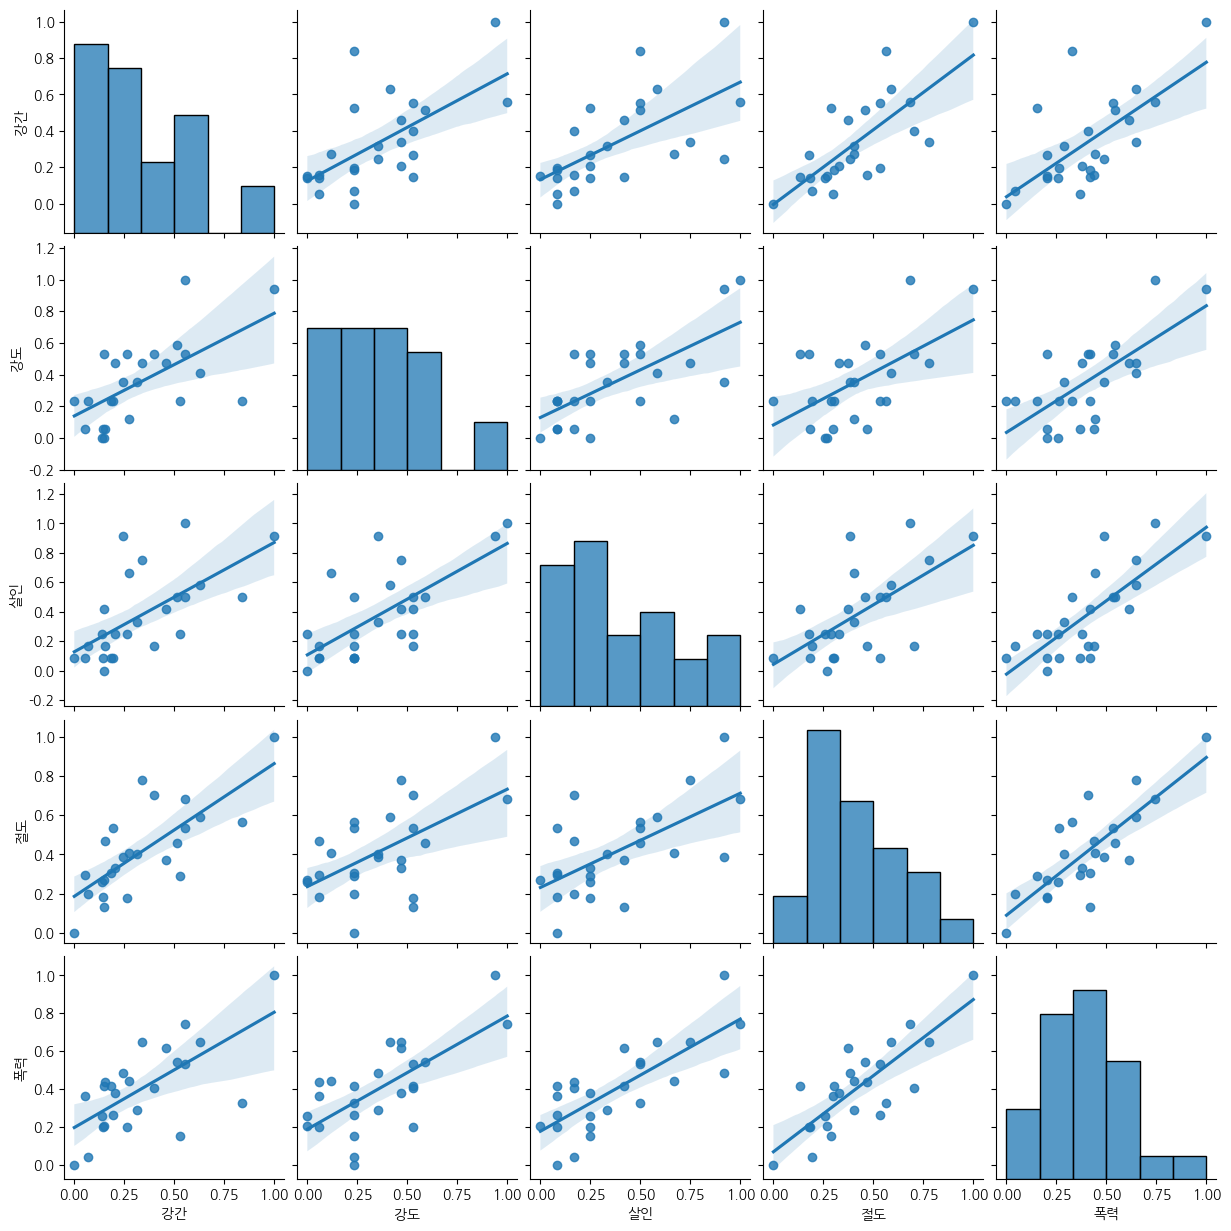

In [39]:
# 강간, 강도, 살인, 폭력, 절도 건수에 대한 상관관계 시각화

sns.pairplot(
  crim_anal_norm,
  vars=col,
  kind='reg'
)

plt.show()

#### CCTV와 살인, 강도에 대한 그래프

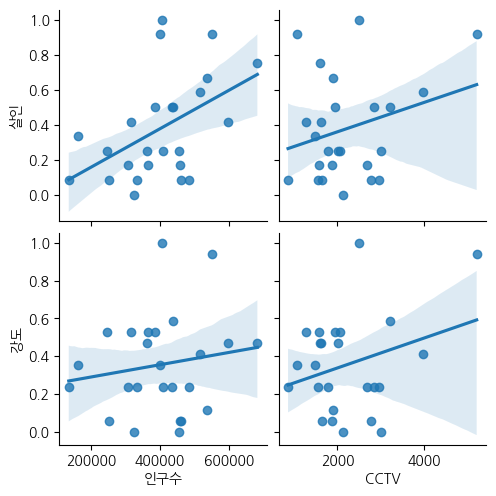

In [40]:
sns.pairplot(
  crim_anal_norm,
  x_vars=['인구수','CCTV'],
  y_vars=['살인','강도'],
  kind='reg'
)

plt.show()

> 인구수가 증가하면 강도와 살인 발생수도 증가한다.  
특히, 강도보다는 살인 발생수가 훨씬 많이 증가한다.   
CCTV와 살인은 상관관계가 있으나 강도에 비해 낮게 보인다.   
따라서 CCTV가 없을 때 살인 사건 발생수가 증가한다.

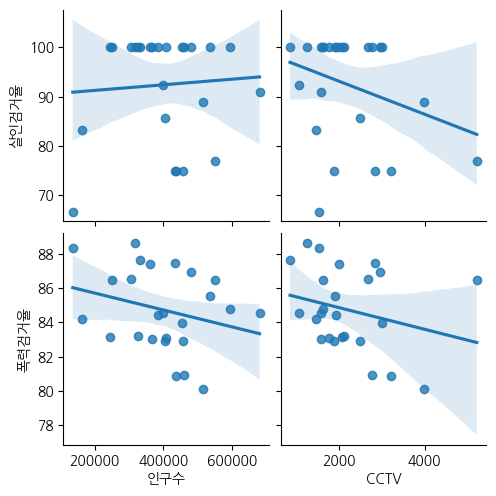

In [41]:
# 인구수, CCTV와 살인 검거율, 폭력 검거율
sns.pairplot(
  crim_anal_norm,
  x_vars=['인구수','CCTV'],
  y_vars=['살인검거율','폭력검거율'],
  kind='reg'
)

plt.show()

---
#### heatmap을 이용한 전체 검거율 확인

In [42]:
# 검거 최대값 가져오기
tmp_max = crim_anal_norm.검거.max()
crim_anal_norm['검거'] == crim_anal_norm['검거'] / 100


# 검거율을 기준으로 정렬
crim_anal_norm_sort = crim_anal_norm.sort_values('검거', ascending=False)

crim_anal_norm_sort.head()

,강간,강도,살인,절도,폭력,강간검거율,강도검거율,살인검거율,절도검거율,폭력검거율,인구수,CCTV,검거,범죄
구별,,,,,,,,,,,,,,
도봉구,0.000000,0.235294,0.083333,0.000000,0.000000,100.000000,100.0,100.0,44.967074,87.626093,333495,858,432.593167,0.318627
금천구,0.141210,0.058824,0.083333,0.180840,0.202717,80.794702,100.0,100.0,56.668794,86.465433,251370,1634,423.928929,0.666924
강서구,0.461095,0.470588,0.416667,0.370649,0.614945,72.900763,100.0,100.0,60.114504,84.752105,595703,1617,417.767372,2.333944
광진구,0.397695,0.529412,0.166667,0.704342,0.406864,91.666667,100.0,100.0,42.200925,83.047619,365990,1581,416.915211,2.204979
동대문구,0.204611,0.470588,0.250000,0.329386,0.379335,84.393064,100.0,100.0,41.090358,87.401884,362793,2003,412.885306,1.633921


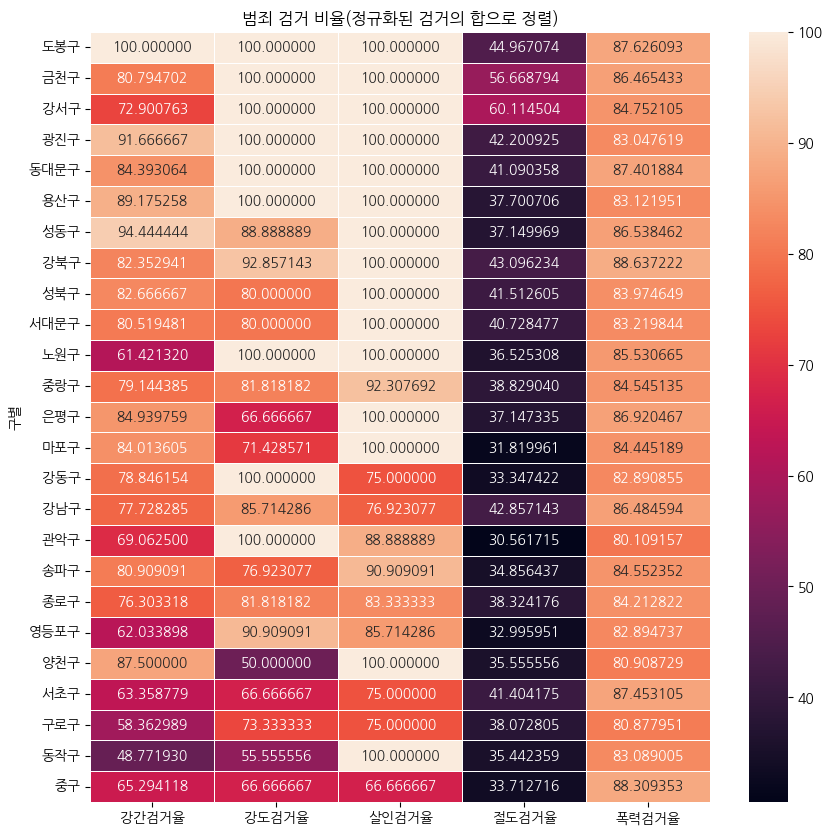

In [43]:
plt.figure(figsize=(10,10))
sns.heatmap(
  crim_anal_norm_sort[col2],
  annot=True,
  fmt='f',
  linewidths=0.5
)

plt.title("범죄 검거 비율(정규화된 검거의 합으로 정렬)")

plt.show()

In [44]:
import json
import folium

In [45]:
# 살인 건수를 서울시 지도에 출력


geo_path = "../Data/skorea_municipalities_geo_simple.json"
geo_str = json.load(open(geo_path, encoding='utf-8'))

seoul = folium.Map(
  location=[37.5502, 126.982],
  zoom_start=10
)

folium.Choropleth(
  geo_data=geo_str,
  data=crim_anal_norm_sort,
  columns=[crim_anal_norm_sort.index, '살인'],
  fill_color='PuRd',
  key_on='feature.properties.name'
).add_to(seoul)

# 위치 정보를 Marker로 표시
for 경찰관서, lat, lng, radius1 in zip(police_address.경찰관서, police_address.lat, police_address.lng, crim_anal_norm_sort.살인검거율):
  popup = folium.Popup(경찰관서, max_width=200)
  folium.Marker(
    [lat,lng],
    popup=popup,
    icon=folium.Icon(color='blue')
  ).add_to(seoul)


  folium.CircleMarker(
    [lat,lng],
    radius=radius1/2.5,
    color='skyblue', # 원의 둘레 색상
    fill_color='skyblue',
    fill=True,
    fill_opacity=0.7
  ).add_to(seoul)


seoul

In [46]:
police_address

,경찰관서,전화번호,FAX,주소,lat,lng
0,서울중부경찰서,(02)2273-4400,(02)2275-3009,서울 중구 수표로 27,37.5676114,126.9902416
1,서울종로경찰서,(02)3701-4324,(02)3701-4223,서울 종로구 율곡로 46,37.5773586,126.9881165
2,서울남대문경찰서,(02)2096-8324,(02)2096-8337,서울 중구 한강대로 410,37.5547114,126.9735286
3,서울서대문경찰서,(02)335-8192,(02)335-8189,서울 서대문구 통일로 113,37.58773,126.946153
4,서울혜화경찰서,(02)762-4400,(02)3158-7133,서울 종로구 창경궁로 112-16,37.5714893,126.9986962
5,서울용산경찰서,(02)2198-0267,(02)2198-0325,서울 용산구 원효로89길 24,37.5404818,126.9679932
6,서울성북경찰서,(02)920-1324,(02)920-1661,서울 성북구 보문로 170,37.5897062,127.0165107
7,서울동대문경찰서,(02)3295-0110,(02)961-4849,서울 동대문구 약령시로21길 29,37.5851345,127.045778
8,서울마포경찰서,(02)3149-6324,(02)3149-6327,서울 마포구 마포대로 183,37.5508598,126.9543356
9,서울영등포경찰서,(02)2118-9324,(02)2118-9461,서울시 영등포구 국회대로 608,37.5263507,126.9006677


In [47]:
station_lat = []
station_lng = []